"""
SmartBuild AI — Full Data Pipeline + ML Model

"""

In [6]:
import os
import re
import pandas as pd
import numpy as np
import os, glob, json, warnings
import warnings
warnings.filterwarnings("ignore")

In [7]:
if __name__ == "__main__":
    print("╔══════════════════════════════════════════════╗")
    print("║       SmartBuild AI — Pipeline Runner       ║")
    print("╚══════════════════════════════════════════════╝")

    RAW_EXCEL_FOLDER = r"Z:\2026\09. Digital Team\Benchmarking\Residential\Data Warehouse"
    all_files = glob.glob(os.path.join(RAW_EXCEL_FOLDER, "*.xlsx"))

    print(f"\nSTEP 1: Found {len(all_files)} Excel files in folder")

    project_rows = []

    for file in all_files:
        print(f"  Reading → {os.path.basename(file)}")

        try:
            # READ PROJECT DATA
            df_proj = pd.read_excel(
                file,
                sheet_name="01 Project Data Input Sheet",
                header=0
            )

            # PIVOT vertical input sheet
            df_proj_pivot = df_proj.set_index("FIELD NAME")["INPUT"].to_dict()

                # READ COST DATA
            df_cost = pd.read_excel(
                    file,
                    sheet_name="02 Cost Data Input Sheet",
                    header=0
                )
            
            # Clean columns   
            df_cost.columns = [str(c).strip() for c in df_cost.columns]
            df_cost = df_cost.loc[:, ~df_cost.columns.duplicated()] 
            
            #DEBUG
            print("\nFile:", os.path.basename(file))
            print("Columns:", df_cost.columns.tolist())

            # Subtotal rows are in HEAD column, not Budget Heads
            df_subtotals = df_cost[
                df_cost["Head"].fillna("").astype(str).str.upper().str.contains("SUBTOTAL", na=False)
                ].copy()

                
            print("Subtotal rows found:", len(df_subtotals))
            print(df_subtotals[["Head", "Budget Heads", "Total"]].head(20))


            # Initialize cost map
                
            cost_map = {
                        "cost_earth_works": 0,
                        "cost_soil_retention": 0,
                        "cost_shell_core": 0,
                        "cost_finishing": 0,
                        "cost_mep": 0,
                        "cost_external_dev": 0
                    }
            
            # Map categories

            for _, row in df_subtotals.iterrows():
                    head = str(row["Head"]).strip().upper()
                    total = pd.to_numeric(row.get("Total", 0), errors="coerce")
                    if pd.isna(total):
                        total = 0

                    if "EARTH" in head:
                        cost_map["cost_earth_works"] = total
                    elif "SOIL" in head or "RETENTION" in head:
                        cost_map["cost_soil_retention"] = total
                    elif "SHELL" in head or "CORE" in head:
                        cost_map["cost_shell_core"] = total
                    elif "FINISH" in head:
                        cost_map["cost_finishing"] = total
                    elif "MEP" in head:
                        cost_map["cost_mep"] = total
                    elif "EXTERNAL" in head or  "DEVELOPMENT" in head:
                        cost_map["cost_external_dev"] = total
                
            print("Cost map:", cost_map)
            print("-" * 70)

            combined = {**df_proj_pivot, **cost_map}
            combined["source_file"] = os.path.basename(file)
            project_rows.append(combined)

        except Exception as e:
            print(f"  ⚠️ Skipped {os.path.basename(file)} — {e}")

    # Combine all projects
    df_raw = pd.DataFrame(project_rows)
    print(f"\n✅ Total projects loaded: {len(df_raw)}")

    # Rename your Excel fields
    df_raw = df_raw.rename(columns={
        "City": "city",
        "Main Category(Height)": "main_category_height",
        "Sub Category(Sector)": "sector",
        "Stage of Budget": "stage_of_budget",
        "Number of Towers": "num_towers",
        "Number of Basement": "num_basement",
        "Number of Podium": "num_podium",
        "Number of Typical Floor": "num_typical_floors",
        "Total Number of Floors": "total_floors",
        "Total Height(In Meter)": "building_height_m",
        "Carpet Area (Sq Ft)": "total_saleable_sqft",
    })

    # Add defaults
    defaults = {
        "city": "Mumbai",
        "main_category_height": "Mid Rise",
        "sector": "Residential",
        "quality_grade": "Standard",
        "stage_of_budget": "DD",
        "num_towers": 1,
        "num_basement": 0,
        "num_podium": 0,
        "num_typical_floors": 15,
        "total_floors": 18,
        "fth_tower_m": 3.0,
        "building_height_m": 50.0,
        "total_saleable_sqft": 50000,
        "total_units": 50,
        "labour_index": 1.0,
        "material_index": 1.0,
        "city_tier": 1,
    }

    for col, val in defaults.items():
        if col not in df_raw.columns:
            df_raw[col] = val

    # Ensure cost columns exist
    cost_cols = [
        "cost_earth_works",
        "cost_soil_retention",
        "cost_shell_core",
        "cost_finishing",
        "cost_mep",
        "cost_external_dev"
    ]

    for c in cost_cols:
        if c not in df_raw.columns:
            df_raw[c] = 0

    # Create total cost + psf
    df_raw["total_project_cost_inr"] = df_raw[cost_cols].sum(axis=1)
    df_raw["total_saleable_sqft"] = pd.to_numeric(df_raw["total_saleable_sqft"], errors="coerce").fillna(50000)
    df_raw["total_builtup_sqft"] = df_raw["total_saleable_sqft"] / 0.70
    df_raw["total_units"] = pd.to_numeric(df_raw["total_units"], errors="coerce").fillna(50)

    df_raw["cost_per_sqft_builtup"] = (
        df_raw["total_project_cost_inr"] / df_raw["total_builtup_sqft"].replace(0, 1)
    )
    df_raw["cost_per_sqft_saleable"] = (
        df_raw["total_project_cost_inr"] / df_raw["total_saleable_sqft"].replace(0, 1)
    )

    print(f"  Cost range: ₹{df_raw['total_project_cost_inr'].min():,.0f} – ₹{df_raw['total_project_cost_inr'].max():,.0f}")

    

╔══════════════════════════════════════════════╗
║       SmartBuild AI — Pipeline Runner       ║
╚══════════════════════════════════════════════╝

STEP 1: Found 33 Excel files in folder
  Reading → Residential 001_SPRE_SDC Sale Sewri.xlsx

File: Residential 001_SPRE_SDC Sale Sewri.xlsx
Columns: ['#', 'Head', 'Budget Heads', 'Tower', 'Non Tower', 'External Development', 'Total', 'Remarks']
Subtotal rows found: 10
                                Head Budget Heads         Total
3             SUBTOTAL - EARTH WORKS          NaN  2.228493e+07
6          SUBTOTAL - SOIL RETENTION          NaN  5.665000e+05
20     SUBTOTAL - SHELL & CORE WORKS          NaN  6.201039e+08
31        SUBTOTAL - FINISHING WORKS          NaN  1.697952e+08
42           SUBTOTAL - FAÇADE WORKS          NaN  1.764811e+08
66              SUBTOTAL - MEP WORKS          NaN  1.807345e+08
69         SUBTOTAL - ELEVATOR WORKS          NaN  2.639250e+07
78    SUBTOTAL - APARTMENT AMENITIES          NaN  5.800000e+06
85      

In [8]:
print(df_raw[[
    "source_file",
    "cost_earth_works",
    "cost_soil_retention",
    "cost_shell_core",
    "cost_finishing",
    "cost_mep",
    "cost_external_dev",
    "total_project_cost_inr",
    "cost_per_sqft_builtup"
]].head(20))


                                          source_file  cost_earth_works  \
0            Residential 001_SPRE_SDC Sale Sewri.xlsx      2.228493e+07   
1           Residential 002_SPRE_SDC Rehab Sewri.xlsx      1.503617e+07   
2   Residential 003_Hines_Hines Residential Devlop...      1.116667e+08   
3   Residential 004_Sterling Buildcon_Crystal Sale...      1.825180e+07   
4   Residential 005_Sterling Buildcon_Crystal Reha...      3.902015e+07   
5   Residential 006_Raymond Realty_Raymond Baya To...      4.348508e+08   
6    Residential 007_Raymond Realty_GS 2 Phase 2.xlsx      1.841953e+08   
7   Residential 008_Raymond Realty_Invictus Tower ...      4.457844e+07   
8      Residential 009_SPRE_SPRE Tower 3 C Thane.xlsx      6.151361e+07   
9   Residential 010_SPRE_Northen Light Sale Thane....      6.834810e+07   
10  Residential 011_SPRE Northen Light Rehab Thane...      0.000000e+00   
11  Residential 012_Adani Realty_Matunga Rehab Tow...      6.226001e+07   
12  Residential 013_Adani

In [ ]:
print("df_raw shape:", df_raw.shape)
print("df_clean shape:", df_clean.shape)
print(df_raw[["total_project_cost_inr", "total_builtup_sqft", "cost_per_sqft_builtup"]].head(10))

df_raw shape: (33, 310)
df_clean shape: (0, 308)
   total_project_cost_inr  total_builtup_sqft  cost_per_sqft_builtup
0            1.035100e+09        2.884129e+05            3588.952999
1            9.020293e+08        2.884129e+05            3127.562556
2            3.132445e+09        5.064101e+05            6185.590877
3            2.082774e+09        5.499810e+05            3786.992653
4            1.989046e+09        4.640216e+05            4286.538441
5            1.007771e+10        2.175357e+06            4632.667751
6            1.227262e+10        2.520793e+06            4868.557013
7            2.213509e+09        3.379588e+05            6549.640639
8            1.188616e+10        1.728314e+06            6877.316448
9            8.300410e+09        2.264378e+06            3665.647142


In [9]:
df_raw["total_project_cost_inr"] = df_raw[cost_cols].sum(axis=1)

In [10]:
print("\nFile:", os.path.basename(file))
print("Subtotal rows found:", len(df_subtotals))
print(df_subtotals[["Head", "Budget Heads", "Total"]].head(20))


File: Residential 035_Runal_Unite.xlsx
Subtotal rows found: 10
                                Head Budget Heads         Total
3             SUBTOTAL - EARTH WORKS          NaN  2.418236e+06
6          SUBTOTAL - SOIL RETENTION          NaN  0.000000e+00
20     SUBTOTAL - SHELL & CORE WORKS          NaN  8.524301e+07
31        SUBTOTAL - FINISHING WORKS          NaN  4.043009e+07
42           SUBTOTAL - FAÇADE WORKS          NaN  2.704862e+07
66              SUBTOTAL - MEP WORKS          NaN  5.566012e+07
69         SUBTOTAL - ELEVATOR WORKS          NaN  5.400000e+06
78    SUBTOTAL - APARTMENT AMENITIES          NaN  0.000000e+00
85        SUBTOTAL - OTHER AMENITIES          NaN  2.690894e+07
101  SUBTOTAL - EXTERNAL DEVELOPMENT          NaN  6.665504e+06


In [11]:
df_cost["Budget Heads"].str.contains("SUBTOTAL")

0      False
1      False
2      False
3      False
4      False
       ...  
99     False
100    False
101    False
102    False
103    False
Name: Budget Heads, Length: 104, dtype: bool

In [12]:
print("df_raw shape:", df_raw.shape)
print(df_raw[[
    "total_project_cost_inr",
    "total_builtup_sqft",
    "cost_per_sqft_builtup"
]].head(10))

df_raw shape: (33, 310)
   total_project_cost_inr  total_builtup_sqft  cost_per_sqft_builtup
0            1.035100e+09        2.884129e+05            3588.952999
1            9.020293e+08        2.884129e+05            3127.562556
2            3.132445e+09        5.064101e+05            6185.590877
3            2.082774e+09        5.499810e+05            3786.992653
4            1.989046e+09        4.640216e+05            4286.538441
5            1.007771e+10        2.175357e+06            4632.667751
6            1.227262e+10        2.520793e+06            4868.557013
7            2.213509e+09        3.379588e+05            6549.640639
8            1.188616e+10        1.728314e+06            6877.316448
9            8.300410e+09        2.264378e+06            3665.647142


In [13]:
print("Rows with cost > 0:", (df_raw["total_project_cost_inr"] > 0).sum())
print("Rows with builtup > 0:", (df_raw["total_builtup_sqft"] > 0).sum())
print("Rows with PSF not null:", df_raw["cost_per_sqft_builtup"].notna().sum())


Rows with cost > 0: 32
Rows with builtup > 0: 33
Rows with PSF not null: 33


In [14]:
import pandas as pd
import numpy as np

def clean_data(df):
    df = df.copy()

    # -------------------------------------------------
    # 1. Standardize column names
    # -------------------------------------------------
    df.columns = [str(c).strip().replace(" ", "_").lower() for c in df.columns]

    # -------------------------------------------------
    # 2. Remove duplicate columns
    # VERY IMPORTANT: prevents df[col] returning DataFrame
    # -------------------------------------------------
    df = df.loc[:, ~df.columns.duplicated()].copy()

    # -------------------------------------------------
    # 3. Remove duplicate rows
    # -------------------------------------------------
    df = df.drop_duplicates()

    # -------------------------------------------------
    # 4. Convert numeric columns
    # -------------------------------------------------
    numeric_cols = [
        "num_towers",
        "num_basement",
        "num_podium",
        "num_typical_floors",
        "total_floors",
        "fth_tower_m",
        "building_height_m",
        "total_saleable_sqft",
        "total_builtup_sqft",
        "total_units",
        "labour_index",
        "material_index",
        "city_tier",
        "cost_earth_works",
        "cost_soil_retention",
        "cost_shell_core",
        "cost_finishing",
        "cost_mep",
        "cost_external_dev",
        "total_project_cost_inr",
        "cost_per_sqft_builtup",
        "cost_per_sqft_saleable"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # -------------------------------------------------
    # 5. Clean text columns safely
    # -------------------------------------------------
    text_cols = list(df.select_dtypes(include=["object"]).columns)

    for col in text_cols:
        # if duplicate somehow still exists, skip or take first column
        if isinstance(df[col], pd.DataFrame):
            df[col] = df[col].iloc[:, 0]

        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace(
            ["nan", "None", "none", "NA", "N/A", ""],
            np.nan
        )

    # -------------------------------------------------
    # 6. Drop rows missing target
    # -------------------------------------------------
    if "cost_per_sqft_builtup" in df.columns:
        df = df.dropna(subset=["cost_per_sqft_builtup"])

    # -------------------------------------------------
    # 7. Fill numeric missing values
    # -------------------------------------------------
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].fillna(df[col].median())

    # -------------------------------------------------
    # 8. Fill categorical missing values
    # -------------------------------------------------
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].fillna("Unknown")

    # -------------------------------------------------
    # 9. Remove impossible rows
    # -------------------------------------------------
    if "total_builtup_sqft" in df.columns:
        df = df[df["total_builtup_sqft"] > 0]

    if "total_project_cost_inr" in df.columns:
        df = df[df["total_project_cost_inr"] > 0]

    return df


In [15]:
print(df_cost.columns.tolist())

['#', 'Head', 'Budget Heads', 'Tower', 'Non Tower', 'External Development', 'Total', 'Remarks']


In [32]:
df_proj.columns.tolist()

['#',
 'SECTION',
 'SUBSECTION',
 'FIELD NAME',
 'INPUT',
 'EXAMPLE/REMARKS',
 'VALUE IDENTIFICATION']

In [16]:
print("File:", os.path.basename(file))
print("Subtotal rows found:", len(df_subtotals))
print("Cost map:", cost_map)
print("-" * 50)

File: Residential 035_Runal_Unite.xlsx
Subtotal rows found: 10
Cost map: {'cost_earth_works': 2418235.8852954134, 'cost_soil_retention': 0.0, 'cost_shell_core': 85243011.9775288, 'cost_finishing': 40430091.733025886, 'cost_mep': 55660121.0, 'cost_external_dev': 6665503.5}
--------------------------------------------------


In [17]:
df_cost.columns = [str(c).strip() for c in df_cost.columns]
print("Cost sheet columns:", df_cost.columns.tolist())

subtotal_col = "Budget Heads"

df_subtotals = df_cost[df_cost[subtotal_col].astype(str).str.contains("SUBTOTAL", case=False, na=False)]



Cost sheet columns: ['#', 'Head', 'Budget Heads', 'Tower', 'Non Tower', 'External Development', 'Total', 'Remarks']


# Defining Feature engineering (X and Y)

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler, LabelEncoder


# def engineer_features(df):
#     df = df.copy()

#     # -------------------------------------------------
#     # 1. Create derived features
#     # -------------------------------------------------
#     # Cost targets
#     y_total = df["total_project_cost_inr"].copy()
#     y_psf   = df["cost_per_sqft_builtup"].copy()
#     y_raw   = df[["total_project_cost_inr", "cost_per_sqft_builtup"]].copy()

#     # Optional engineered ratios
#     if "total_builtup_sqft" in df.columns:
#         df["cost_shell_core_psf"] = df["cost_shell_core"] / df["total_builtup_sqft"].replace(0, np.nan)
#         df["cost_finishing_psf"]  = df["cost_finishing"] / df["total_builtup_sqft"].replace(0, np.nan)
#         df["cost_mep_psf"]        = df["cost_mep"] / df["total_builtup_sqft"].replace(0, np.nan)
#         df["cost_external_psf"]   = df["cost_external_dev"] / df["total_builtup_sqft"].replace(0, np.nan)

#     # Height category (simple rule)
#     def height_bucket(floors):
#         try:
#             floors = float(floors)
#             if floors <= 10:
#                 return "Low Rise"
#             elif floors <= 25:
#                 return "Mid Rise"
#             else:
#                 return "High Rise"
#         except:
#             return "Unknown"

#     if "total_floors" in df.columns:
#         df["height_category"] = df["total_floors"].apply(height_bucket)
#     else:
#         df["height_category"] = "Unknown"

#     # -------------------------------------------------
#     # 2. Select useful features(X)
#     # -------------------------------------------------
   
#     feature_cols_model_1 = [
#         "city",
#         "main_category_height",
#         "sector",
#         "quality_grade",
#         "stage_of_budget",
#         "num_towers",
#         "num_basement",
#         "num_podium",
#         "num_typical_floors",
#         "total_floors",
#         "fth_tower_m",
#         "building_height_m",
#         "total_saleable_sqft",
#         "total_builtup_sqft",
#         "total_units",
#         "labour_index",
#         "material_index",
#         "city_tier",
#         "cost_earth_works", 
#         "cost_soil_retention",
#         "cost_shell_core",
#         "cost_finishing",
#         "cost_mep",
#         "cost_external_dev",
#         "cost_shell_core_psf",
#         "cost_finishing_psf",
#         "cost_mep_psf",
#         "cost_external_psf",
#         "height_category"
#     ] 
    
#     feature_cols_model_2 = [
#     "city",
#     "main_category_height",
#     "sector",
#     "quality_grade",
#     "stage_of_budget",
#     "num_towers",
#     "num_basement",
#     "num_podium",
#     "num_typical_floors",
#     "total_floors",
#     "fth_tower_m",
#     "building_height_m",
#     "total_saleable_sqft",
#     "total_builtup_sqft",
#     "total_units",
#     "labour_index",
#     "material_index",
#     "city_tier",
#     "height_category"
#     ]
#     # Keep only columns that actually exist(X columns)
#     feature_cols = [c for c in feature_cols if c in df.columns]

#     X1 = df[feature_cols_model_1].copy()
#     X2 = df[feature_cols_model_2].copy()
#     X3 = df[feature_cols_model_3].copy()

#     # -------------------------------------------------
#     # 3. Encode categorical columns
#     # -------------------------------------------------
#     encoders = {}
#     cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

#     for col in cat_cols:
#         le = LabelEncoder()
#         X[col] = X[col].astype(str).fillna("Unknown")
#         X[col] = le.fit_transform(X[col])
#         encoders[col] = le

#     # -------------------------------------------------
#     # 4. Fill any remaining missing values
#     # -------------------------------------------------
#     for col in X.columns:
#         if pd.api.types.is_numeric_dtype(X[col]):
#             X[col] = X[col].fillna(X[col].median())
#         else:
#             X[col] = X[col].fillna("Unknown")

#     # -------------------------------------------------
#     # 5. Scale features
#     # -------------------------------------------------
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)

#     return X, X_scaled, y_total, y_psf, y_raw, feature_cols, scaler, encoders 

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np
import pandas as pd

def train_models(X_scaled, y_total, y_psf, y_raw, feature_cols):
    """
    Train multiple models and select the best based on MAPE.
    Main target = cost per sqft builtup (y_psf)
    """

    # -------------------------------------------------
    # 1. Use cost_per_sqft as main target
    # -------------------------------------------------
    y = y_psf.copy()

    # Safety checks
    if len(y) == 0:
        raise ValueError("No target rows available in y_psf")
    if X_scaled.shape[0] == 0:
        raise ValueError("X_scaled is empty")
    if X_scaled.shape[0] != len(y):
        raise ValueError(f"Mismatch: X_scaled rows={X_scaled.shape[0]}, y rows={len(y)}")

    # -------------------------------------------------
    # 2. Train-test split
    # -------------------------------------------------
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # -------------------------------------------------
    # 3. Models
    # -------------------------------------------------
    models = {
        "Ridge Regression": Ridge(alpha=1.0),
        "Random Forest": RandomForestRegressor(
            n_estimators=100,
            max_depth=5,
            random_state=42
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    }

    results = {}
    best_model = None
    best_name = None
    best_mape = np.inf

    print("\n============================================================")
    print("STEP 5: MODEL TRAINING & EVALUATION")
    print("============================================================")

    # -------------------------------------------------
    # 4. Train + evaluate
    # -------------------------------------------------
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)

        mape = mean_absolute_percentage_error(y_te, preds) * 100
        rmse = np.sqrt(mean_squared_error(y_te, preds))
        r2   = r2_score(y_te, preds)

        results[name] = {
            "MAPE": round(mape, 2),
            "R2": round(r2, 3),
            "RMSE": round(rmse, 2)
        }

        print(f"\n── {name} ──")
        print(f"   MAPE: {mape:.2f}%")
        print(f"   R²:   {r2:.3f}")
        print(f"   RMSE: {rmse:.2f}")

        if mape < best_mape:
            best_mape = mape
            best_model = model
            best_name = name

    print(f"\n🏆 BEST MODEL: {best_name} (MAPE: {best_mape:.2f}%)")

    return best_model, best_name, results, X_te, y_te

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def feature_importance(model, feature_cols, model_name):
    print("\n============================================================")
    print("STEP 6: FEATURE IMPORTANCE")
    print("============================================================")

    if hasattr(model, "feature_importances_"):
        imp = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False)

        print(imp.head(15))

        plt.figure(figsize=(10, 6))
        plt.barh(imp["Feature"].head(15)[::-1], imp["Importance"].head(15)[::-1])
        plt.title(f"Feature Importance — {model_name}")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()

    elif hasattr(model, "coef_"):
        imp = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": np.abs(model.coef_)
        }).sort_values("Importance", ascending=False)

        print(imp.head(15))

        plt.figure(figsize=(10, 6))
        plt.barh(imp["Feature"].head(15)[::-1], imp["Importance"].head(15)[::-1])
        plt.title(f"Feature Importance — {model_name}")
        plt.xlabel("Absolute Coefficient")
        plt.tight_layout()
        plt.show()

    else:
        print(f"No feature importance available for model: {model_name}")

df_clean shape: (32, 308)
X shape: (32, 19)
X_scaled shape: (32, 19)

STEP 5: MODEL TRAINING & EVALUATION

── Ridge Regression ──
   MAPE: 149.95%
   R²:   -70.651
   RMSE: 10290.08

── Random Forest ──
   MAPE: 18.80%
   R²:   -0.091
   RMSE: 1269.51

── Gradient Boosting ──
   MAPE: 11.52%
   R²:   0.631
   RMSE: 738.62

🏆 BEST MODEL: Gradient Boosting (MAPE: 11.52%)

STEP 6: FEATURE IMPORTANCE
                 Feature  Importance
12   total_saleable_sqft    0.537095
13    total_builtup_sqft    0.395514
11     building_height_m    0.028853
9           total_floors    0.016085
6           num_basement    0.010110
8     num_typical_floors    0.006827
7             num_podium    0.002905
4        stage_of_budget    0.001103
1   main_category_height    0.000613
5             num_towers    0.000470
0                   city    0.000318
18       height_category    0.000107
2                 sector    0.000000
10           fth_tower_m    0.000000
3          quality_grade    0.000000


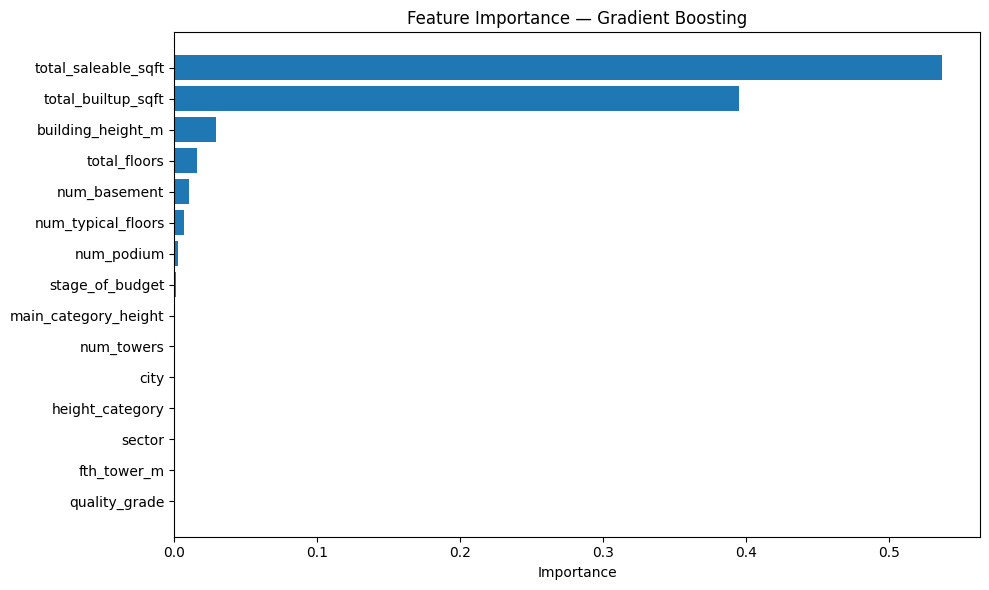

In [42]:
# =====================================================
# STEP 3: CLEAN
# =====================================================
df_clean = clean_data(df_raw)

print("df_clean shape:", df_clean.shape)

# =====================================================
# STEP 4: FEATURE ENGINEERING
# =====================================================
X, X_scaled, y_total, y_psf, y_raw, feature_cols, scaler, encoders = engineer_features(df_clean)

print("X shape:", X.shape)
print("X_scaled shape:", X_scaled.shape)

# =====================================================
# STEP 5: TRAIN
# =====================================================
best_model, best_name, results, X_te, yr_te = train_models(
    X_scaled, y_total, y_psf, y_raw, feature_cols
)

# =====================================================
# STEP 6: FEATURE IMPORTANCE
# =====================================================
feature_importance(best_model, feature_cols, best_name)




In [24]:
import os
BASE_DIR = r"C:\Users\shivani.thakur\OneDrive - WTP Australia Pty Ltd\Documents\Shivani-Cost_Model\Smartbuild"
print("BASE_DIR exists:", os.path.exists(BASE_DIR))

print("Parent exists:", os.path.exists(os.path.dirname(BASE_DIR)))
print("Parent path:", os.path.dirname(BASE_DIR))


BASE_DIR exists: True
Parent exists: True
Parent path: C:\Users\shivani.thakur\OneDrive - WTP Australia Pty Ltd\Documents\Shivani-Cost_Model


In [ ]:
import os
import joblib
import pandas as pd

BASE_DIR = r"C:\Users\shivani.thakur\Documents\Smartbuild"

# Create base directory first
os.makedirs(BASE_DIR, exist_ok=True)

TRAINED_DIR = os.path.join(BASE_DIR, "models", "trained")
EXPERIMENTS_DIR = os.path.join(BASE_DIR, "models", "experiments")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

os.makedirs(TRAINED_DIR, exist_ok=True)
os.makedirs(EXPERIMENTS_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(TRAINED_DIR, "best_model_v1.pkl"))
joblib.dump(scaler, os.path.join(TRAINED_DIR, "scaler_v1.pkl"))
joblib.dump(encoders, os.path.join(TRAINED_DIR, "encoders_v1.pkl"))

results_df = pd.DataFrame(results).T
results_df.to_csv(os.path.join(EXPERIMENTS_DIR, "model_comparison.csv"))

df_clean.to_csv(os.path.join(PROCESSED_DIR, "cleaned_project_data.csv"), index=False)

print("✅ Saved successfully")

✅ Saved successfully


In [27]:
import os
import joblib
import pandas as pd

BASE_DIR = r"C:\Users\shivani.thakur\Documents\Smartbuild"

# Ensure base folder exists
os.makedirs(BASE_DIR, exist_ok=True)

TRAINED_DIR = os.path.join(BASE_DIR, "models", "trained")
EXPERIMENTS_DIR = os.path.join(BASE_DIR, "models", "experiments")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

os.makedirs(TRAINED_DIR, exist_ok=True)
os.makedirs(EXPERIMENTS_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save model artifacts
joblib.dump(best_model, os.path.join(TRAINED_DIR, "best_model_v1.pkl"))
joblib.dump(scaler, os.path.join(TRAINED_DIR, "scaler_v1.pkl"))
joblib.dump(encoders, os.path.join(TRAINED_DIR, "encoders_v1.pkl"))
joblib.dump(feature_cols, os.path.join(TRAINED_DIR, "feature_cols_v1.pkl"))

# Save comparison + cleaned data
results_df = pd.DataFrame(results).T
results_df.to_csv(os.path.join(EXPERIMENTS_DIR, "model_comparison.csv"))

df_clean.to_csv(os.path.join(PROCESSED_DIR, "cleaned_project_data.csv"), index=False)

print("\n📁 Saved successfully:")
print(os.path.join(TRAINED_DIR, "best_model_v1.pkl"))
print(os.path.join(TRAINED_DIR, "scaler_v1.pkl"))
print(os.path.join(TRAINED_DIR, "encoders_v1.pkl"))
print(os.path.join(TRAINED_DIR, "feature_cols_v1.pkl"))
print(os.path.join(EXPERIMENTS_DIR, "model_comparison.csv"))
print(os.path.join(PROCESSED_DIR, "cleaned_project_data.csv"))


📁 Saved successfully:
C:\Users\shivani.thakur\Documents\Smartbuild\models\trained\best_model_v1.pkl
C:\Users\shivani.thakur\Documents\Smartbuild\models\trained\scaler_v1.pkl
C:\Users\shivani.thakur\Documents\Smartbuild\models\trained\encoders_v1.pkl
C:\Users\shivani.thakur\Documents\Smartbuild\models\trained\feature_cols_v1.pkl
C:\Users\shivani.thakur\Documents\Smartbuild\models\experiments\model_comparison.csv
C:\Users\shivani.thakur\Documents\Smartbuild\data\processed\cleaned_project_data.csv


In [26]:
import os

BASE_DIR = r"C:\Users\shivani.thakur\Documents\Smartbuild"
os.makedirs(BASE_DIR, exist_ok=True)

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("Using BASE_DIR:", BASE_DIR)

BASE_DIR exists: True
Using BASE_DIR: C:\Users\shivani.thakur\Documents\Smartbuild


5) Exact code pattern for soil/location integration

A. Pincode lookup

In [29]:
import requests

def get_pincode_details(pincode: str):
    url = f"https://api.postalpincode.in/pincode/{pincode}"
    r = requests.get(url, timeout=10)
    data = r.json()

    if not data or data[0].get("Status") != "Success":
        return None

    post_offices = data[0].get("PostOffice", [])
    if not post_offices:
        return None

    po = post_offices[0]
    return {
        "state": po.get("State"),
        "district": po.get("District"),
        "region": po.get("Region"),
        "circle": po.get("Circle"),
        "area_name": po.get("Name")
    }

B. Geocode to lat/lon

In [30]:
def geocode_address(query: str):
    import requests

    url = "https://nominatim.openstreetmap.org/search"
    params = {
        "q": query,
        "format": "jsonv2",
        "limit": 1,
        "addressdetails": 1
    }
    headers = {"User-Agent": "SmartBuildAI/1.0"}
    r = requests.get(url, params=params, headers=headers, timeout=15)
    data = r.json()

    if not data:
        return None

    return {
        "lat": float(data[0]["lat"]),
        "lon": float(data[0]["lon"]),
        "display_name": data[0].get("display_name")
    }

C. SoilGrids query

In [28]:
def derive_soil_factors(soil_json):
    """
    Convert raw SoilGrids response into practical estimation features.
    You should refine this once you inspect real API responses.
    """
    clay_score = 0
    sand_score = 0
    silt_score = 0
    ph_score = 0

    # Placeholder parsing (depends on exact SoilGrids response structure)
    # After first real response, we can refine this block properly.

    excavation_difficulty = 1.0
    soil_retention_factor = 1.0

    # Example logic
    if clay_score > 40:
        excavation_difficulty = 1.10
        soil_retention_factor = 1.15

    return {
        "soil_risk_score": (clay_score + silt_score) / 2 if (clay_score or silt_score) else 0,
        "excavation_factor": excavation_difficulty,
        "soil_retention_factor": soil_retention_factor
    }

D. Convert soil response into model-friendly features

In [31]:
def derive_soil_factors(soil_json):
    """
    Convert raw SoilGrids response into practical estimation features.
    You should refine this once you inspect real API responses.
    """
    clay_score = 0
    sand_score = 0
    silt_score = 0
    ph_score = 0

    # Placeholder parsing (depends on exact SoilGrids response structure)
    # After first real response, we can refine this block properly.

    excavation_difficulty = 1.0
    soil_retention_factor = 1.0

    # Example logic
    if clay_score > 40:
        excavation_difficulty = 1.10
        soil_retention_factor = 1.15

    return {
        "soil_risk_score": (clay_score + silt_score) / 2 if (clay_score or silt_score) else 0,
        "excavation_factor": excavation_difficulty,
        "soil_retention_factor": soil_retention_factor
    }

In [33]:
import os
import requests
import pandas as pd
from datetime import datetime

# ============================================================
# CONFIG
# ============================================================
TE_API_KEY = os.getenv("TE_API_KEY", "")
METALS_API_KEY = os.getenv("METALS_API_KEY", "")
COMMODITIES_API_KEY = os.getenv("COMMODITIES_API_KEY", "")

# Local benchmark table for materials that do NOT have a clean live API
# You can move this into Excel later (RATE_MASTER.xlsx / city sheet)
LOCAL_BENCHMARK_RATES = {
    "Mumbai MMR": {
        "Cement OPC 53": {"unit": "bag", "rate_inr": 380, "source": "local_benchmark"},
        "River Sand": {"unit": "cuft", "rate_inr": 55, "source": "local_benchmark"},
        "M Sand": {"unit": "cuft", "rate_inr": 35, "source": "local_benchmark"},
        "Aggregate 20mm": {"unit": "cuft", "rate_inr": 48, "source": "local_benchmark"},
        "Labour": {"unit": "day", "rate_inr": 900, "source": "local_benchmark"},
    },
    "Pune": {
        "Cement OPC 53": {"unit": "bag", "rate_inr": 355, "source": "local_benchmark"},
        "River Sand": {"unit": "cuft", "rate_inr": 42, "source": "local_benchmark"},
        "M Sand": {"unit": "cuft", "rate_inr": 30, "source": "local_benchmark"},
        "Aggregate 20mm": {"unit": "cuft", "rate_inr": 40, "source": "local_benchmark"},
        "Labour": {"unit": "day", "rate_inr": 750, "source": "local_benchmark"},
    },
}

# ============================================================
# PROVIDER 1: TRADING ECONOMICS (recommended for live steel)
# Docs expose markets/category and symbol endpoints; Python package also provides commodity access.
# Replace symbol after testing against your account subscription / available symbol list.
# ============================================================
def fetch_steel_from_tradingeconomics(symbol="steel", currency="USD"):
    """
    Fetch live steel market reference quote from Trading Economics.
    NOTE:
    - Their docs support Markets and Symbols endpoints.
    - Depending on plan/account, symbol naming may vary.
    - Start by testing steel-related symbols available in your account.
    """
    if not TE_API_KEY:
        return None

    # Option A: general markets commodities list
    url = f"https://api.tradingeconomics.com/markets?c={TE_API_KEY}&f=json"
    try:
        r = requests.get(url, timeout=20)
        r.raise_for_status()
        data = r.json()

        # Try to find a steel quote from the returned markets list
        steel_rows = []
        for row in data:
            name = str(row.get("Name", "")).lower()
            ticker = str(row.get("Ticker", "")).lower()
            country = str(row.get("Country", "")).lower()
            if "steel" in name or "steel" in ticker:
                steel_rows.append(row)

        if not steel_rows:
            return None

        # Take first matching steel row (you can refine later)
        row = steel_rows[0]

        return {
            "material": "Steel TMT / Rebar (reference)",
            "unit": row.get("unit", row.get("Unit", "market_unit")),
            "currency": row.get("unit", currency),
            "raw_price": row.get("Last"),
            "timestamp": row.get("LastUpdate") or row.get("Date"),
            "provider": "TradingEconomics",
            "provider_symbol": row.get("Symbol") or row.get("Ticker"),
            "notes": f"Reference market quote from Trading Economics: {row.get('Name')}"
        }

    except Exception as e:
        print(f"[TE] error: {e}")
        return None


# ============================================================
# PROVIDER 2: METALS-API / COMMODITIES-API fallback
# Supports steel symbols such as STEEL-HR and STEEL-RE.
# These are market references, NOT local site-delivered Indian rates.
# ============================================================
def fetch_steel_from_metals_api(symbol="STEEL-RE"):
    """
    Fetch steel reference quote from Metals-API.
    Example symbols:
      STEEL-RE = LME Steel Rebar FOB Turkey
      STEEL-HR = LME Steel HRC FOB China
    """
    if not METALS_API_KEY:
        return None

    url = f"https://metals-api.com/api/latest?access_key={METALS_API_KEY}&base=USD&symbols={symbol}"
    try:
        r = requests.get(url, timeout=20)
        r.raise_for_status()
        data = r.json()

        rates = data.get("rates", {})
        if symbol not in rates:
            return None

        return {
            "material": "Steel TMT / Rebar (reference)",
            "unit": "market_unit",
            "currency": "USD",
            "raw_price": rates[symbol],
            "timestamp": data.get("date"),
            "provider": "MetalsAPI",
            "provider_symbol": symbol,
            "notes": "Reference market quote from Metals-API"
        }

    except Exception as e:
        print(f"[MetalsAPI] error: {e}")
        return None


def fetch_steel_from_commodities_api(symbol="STEEL-RE"):
    """
    Optional Commodities-API fallback if you prefer it over Metals-API.
    """
    if not COMMODITIES_API_KEY:
        return None

    url = f"https://commodities-api.com/api/latest?access_key={COMMODITIES_API_KEY}&base=USD&symbols={symbol}"
    try:
        r = requests.get(url, timeout=20)
        r.raise_for_status()
        data = r.json()

        rates = data.get("rates", {})
        if symbol not in rates:
            return None

        return {
            "material": "Steel TMT / Rebar (reference)",
            "unit": "market_unit",
            "currency": "USD",
            "raw_price": rates[symbol],
            "timestamp": data.get("date"),
            "provider": "CommoditiesAPI",
            "provider_symbol": symbol,
            "notes": "Reference market quote from Commodities-API"
        }

    except Exception as e:
        print(f"[CommoditiesAPI] error: {e}")
        return None


# ============================================================
# NORMALIZATION HELPERS
# ============================================================
def convert_market_steel_to_inr_per_kg(raw_price, usd_inr=83.0, assumed_market_unit="per_tonne"):
    """
    Convert a steel market reference quote into INR/kg.

    IMPORTANT:
    Market APIs can expose different unit conventions depending on symbol/provider.
    For production use, verify the exact contract/unit for the chosen symbol and
    calibrate the conversion once.

    Here we assume the raw quote is roughly USD per metric tonne for a steel reference.
    INR/kg = (USD/tonne * USDINR) / 1000
    """
    if raw_price is None:
        return None

    if assumed_market_unit == "per_tonne":
        return round((raw_price * usd_inr) / 1000, 2)

    # fallback
    return round(raw_price * usd_inr, 2)


def get_local_benchmark_rate(region, material):
    region_rates = LOCAL_BENCHMARK_RATES.get(region, {})
    return region_rates.get(material)


# ============================================================
# MAIN RATE ENGINE
# ============================================================
def fetch_material_rates(region="Mumbai MMR", usd_inr=83.0):
    """
    Returns a normalized DataFrame of current material rates.
    """

    rates = []

    # ---------------------------------------------
    # 1) STEEL — try live APIs first
    # ---------------------------------------------
    steel_quote = (
        fetch_steel_from_tradingeconomics()
        or fetch_steel_from_metals_api("STEEL-RE")
        or fetch_steel_from_commodities_api("STEEL-RE")
    )

    if steel_quote:
        steel_inr_per_kg = convert_market_steel_to_inr_per_kg(
            steel_quote["raw_price"],
            usd_inr=usd_inr,
            assumed_market_unit="per_tonne"
        )
        rates.append({
            "material": "Steel TMT",
            "unit": "kg",
            "rate_inr": steel_inr_per_kg,
            "rate_type": "live_reference",
            "provider": steel_quote["provider"],
            "provider_symbol": steel_quote["provider_symbol"],
            "timestamp": steel_quote["timestamp"],
            "notes": steel_quote["notes"]
        })
    else:
        # fallback benchmark
        rates.append({
            "material": "Steel TMT",
            "unit": "kg",
            "rate_inr": 68.5,
            "rate_type": "fallback_benchmark",
            "provider": "manual_default",
            "provider_symbol": "",
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "notes": "Fallback benchmark rate"
        })

    # ---------------------------------------------
    # 2) LOCAL MATERIALS — benchmark / manual layer
    # ---------------------------------------------
    for material in ["Cement OPC 53", "River Sand", "M Sand", "Aggregate 20mm", "Labour"]:
        base = get_local_benchmark_rate(region, material)
        if base:
            rates.append({
                "material": material,
                "unit": base["unit"],
                "rate_inr": base["rate_inr"],
                "rate_type": "local_benchmark",
                "provider": base["source"],
                "provider_symbol": "",
                "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "notes": f"Region benchmark for {region}"
            })

    return pd.DataFrame(rates)


# ============================================================
# OPTIONAL: SAVE RATE MASTER SNAPSHOT
# ============================================================
def save_rate_master_snapshot(df_rates, output_path="RATE_MASTER_LIVE.xlsx"):
    df_rates.to_excel(output_path, index=False)
    return output_path


# ============================================================
# TEST
# ============================================================
if __name__ == "__main__":
    df_rates = fetch_material_rates(region="Mumbai MMR", usd_inr=83.0)
    print(df_rates)

         material  unit  rate_inr           rate_type         provider  \
0       Steel TMT    kg      68.5  fallback_benchmark   manual_default   
1   Cement OPC 53   bag     380.0     local_benchmark  local_benchmark   
2      River Sand  cuft      55.0     local_benchmark  local_benchmark   
3          M Sand  cuft      35.0     local_benchmark  local_benchmark   
4  Aggregate 20mm  cuft      48.0     local_benchmark  local_benchmark   
5          Labour   day     900.0     local_benchmark  local_benchmark   

  provider_symbol            timestamp                            notes  
0                  2026-05-26 14:43:33          Fallback benchmark rate  
1                  2026-05-26 14:43:33  Region benchmark for Mumbai MMR  
2                  2026-05-26 14:43:33  Region benchmark for Mumbai MMR  
3                  2026-05-26 14:43:33  Region benchmark for Mumbai MMR  
4                  2026-05-26 14:43:33  Region benchmark for Mumbai MMR  
5                  2026-05-26 14:43:3

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# ============================================================
# STEP 1: DEFINE FEATURE LIST
# ============================================================
feature_cols = [
    "city",
    "main_category_height",
    "sector",
    "quality_grade",
    "stage_of_budget",
    "num_towers",
    "num_basement",
    "num_podium",
    "num_typical_floors",
    "total_floors",
    "fth_tower_m",
    "building_height_m",
    "total_saleable_sqft",
    "total_builtup_sqft",
    "total_units",
    "labour_index",
    "material_index",
    "city_tier",
    "cost_earth_works",
    "cost_soil_retention",
    "cost_shell_core",
    "cost_finishing",
    "cost_mep",
    "cost_external_dev",
    "cost_shell_core_psf",
    "cost_finishing_psf",
    "cost_mep_psf",
    "cost_external_psf",
    "height_category"
]

target_col = "cost_per_sqft_builtup"   # main y
total_target_col = "total_project_cost_inr"  # optional reference


# ============================================================
# STEP 2: SEPARATE CATEGORICAL + NUMERIC
# ============================================================
categorical_cols = [
    "city",
    "main_category_height",
    "sector",
    "quality_grade",
    "stage_of_budget",
    "height_category"
]

numeric_cols = [col for col in feature_cols if col not in categorical_cols]


# ============================================================
# STEP 3: PREP DATA
# ============================================================
def prepare_training_data(df):
    df = df.copy()

    # standardize columns
    df.columns = [str(c).strip().replace(" ", "_").lower() for c in df.columns]

    # -------------------------------------------------
    # 1. create missing derived columns
    # -------------------------------------------------

    # height_category
    if "height_category" not in df.columns:
        def get_height_category(x):
            try:
                x = float(x)
                if x <= 10:
                    return "low_rise"
                elif x <= 25:
                    return "mid_rise"
                else:
                    return "high_rise"
            except:
                return "unknown"

        if "total_floors" in df.columns:
            df["height_category"] = df["total_floors"].apply(get_height_category)
        else:
            df["height_category"] = "unknown"

    # cost psf features
    if "total_builtup_sqft" not in df.columns:
        raise ValueError("Missing column: total_builtup_sqft")

    builtup = df["total_builtup_sqft"].replace(0, np.nan)

    if "cost_shell_core_psf" not in df.columns:
        df["cost_shell_core_psf"] = df["cost_shell_core"] / builtup if "cost_shell_core" in df.columns else 0

    if "cost_finishing_psf" not in df.columns:
        df["cost_finishing_psf"] = df["cost_finishing"] / builtup if "cost_finishing" in df.columns else 0

    if "cost_mep_psf" not in df.columns:
        df["cost_mep_psf"] = df["cost_mep"] / builtup if "cost_mep" in df.columns else 0

    if "cost_external_psf" not in df.columns:
        df["cost_external_psf"] = df["cost_external_dev"] / builtup if "cost_external_dev" in df.columns else 0

    # replace inf/nan after division
    for c in ["cost_shell_core_psf", "cost_finishing_psf", "cost_mep_psf", "cost_external_psf"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)

    # -------------------------------------------------
    # 2. keep only required columns + target
    # -------------------------------------------------
    required_cols = feature_cols + [target_col, total_target_col]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in dataframe: {missing_cols}")

    # -------------------------------------------------
    # 3. drop rows with missing target
    # -------------------------------------------------
    df = df.dropna(subset=[target_col])

    # fill categorical
    for c in categorical_cols:
        df[c] = df[c].astype(str).fillna("Unknown")

    # fill numeric
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median())

    X = df[feature_cols].copy()
    y_psf = df[target_col].copy()
    y_total = df[total_target_col].copy()

    return X, y_psf, y_total

    # keep only required columns + target
    required_cols = feature_cols + [target_col, total_target_col]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in dataframe: {missing_cols}")

    # drop rows with missing target
    df = df.dropna(subset=[target_col])

    # fill missing categorical with Unknown
    for c in categorical_cols:
        df[c] = df[c].astype(str).fillna("Unknown")

    # fill missing numeric with median
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median())

    X = df[feature_cols].copy()
    y_psf = df[target_col].copy()
    y_total = df[total_target_col].copy()

    return X, y_psf, y_total


# ============================================================
# STEP 4: PREPROCESSORS
# ============================================================
# Ridge needs scaling on numeric + one-hot on categorical
preprocessor_ridge = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

# Tree models do not need scaling, only one-hot encoding for categoricals
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)


# ============================================================
# STEP 5: DEFINE 3 MODELS
# ============================================================
models = {
    "Ridge Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_ridge),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),
}


# ============================================================
# STEP 6: TRAIN + EVALUATE ALL 3
# ============================================================
def train_all_models(df):
    X, y_psf, y_total = prepare_training_data(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_psf, test_size=0.2, random_state=42
    )

    results = {}
    best_model = None
    best_name = None
    best_mape = np.inf

    print("\n============================================================")
    print("TRAINING 3 MODELS WITH ENCODING + PIPELINE")
    print("============================================================")

    for name, pipe in models.items():
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        mape = mean_absolute_percentage_error(y_test, preds) * 100
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        results[name] = {
            "MAPE": round(mape, 2),
            "R2": round(r2, 3),
            "RMSE": round(rmse, 2)
        }

        print(f"\n── {name} ──")
        print(f"   MAPE: {mape:.2f}%")
        print(f"   R²:   {r2:.3f}")
        print(f"   RMSE: {rmse:.2f}")

        if mape < best_mape:
            best_mape = mape
            best_model = pipe
            best_name = name

    print(f"\n🏆 BEST MODEL: {best_name} (MAPE: {best_mape:.2f}%)")

    return best_model, best_name, results, X_test, y_test


# ============================================================
# STEP 7: FEATURE IMPORTANCE
# ============================================================
def feature_importance_from_pipeline(best_model, model_name):
    print("\n============================================================")
    print("FEATURE IMPORTANCE")
    print("============================================================")

    # get transformed feature names
    preprocessor = best_model.named_steps["preprocessor"]
    model = best_model.named_steps["model"]

    try:
        transformed_feature_names = preprocessor.get_feature_names_out()
    except:
        transformed_feature_names = [f"feature_{i}" for i in range(
            len(preprocessor.transform(pd.DataFrame([{
                c: 0 if c in numeric_cols else "Unknown" for c in feature_cols
            }])).toarray()[0])
        )]

    # tree-based feature importances
    if hasattr(model, "feature_importances_"):
        imp = pd.DataFrame({
            "Feature": transformed_feature_names,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False)

        print(imp.head(20))
        return imp

    # linear coefficients
    elif hasattr(model, "coef_"):
        imp = pd.DataFrame({
            "Feature": transformed_feature_names,
            "Importance": np.abs(model.coef_)
        }).sort_values("Importance", ascending=False)

        print(imp.head(20))
        return imp

    else:
        print(f"No feature importance available for {model_name}")
        return None


# ============================================================
# STEP 8: SAVE BEST MODEL
# ============================================================
def save_best_model(best_model, best_name, results, save_dir=r"C:\Users\shivani.thakur\Documents\Smartbuild\models\trained"):
    os.makedirs(save_dir, exist_ok=True)

    model_path = os.path.join(save_dir, "best_model_pipeline_v1.pkl")
    metadata_path = os.path.join(save_dir, "best_model_metadata_v1.pkl")

    metadata = {
        "best_model_name": best_name,
        "feature_cols": feature_cols,
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols,
        "target_col": target_col,
        "results": results
    }

    joblib.dump(best_model, model_path)
    joblib.dump(metadata, metadata_path)

    print("\n✅ Saved:")
    print(model_path)
    print(metadata_path)


# ============================================================
# STEP 9: RUN
# ============================================================
# Example usage:
best_model, best_name, results, X_test, y_test = train_all_models(df_clean)
feature_imp_df = feature_importance_from_pipeline(best_model, best_name)
save_best_model(best_model, best_name, results)



TRAINING 3 MODELS WITH ENCODING + PIPELINE

── Ridge Regression ──
   MAPE: 12.19%
   R²:   0.650
   RMSE: 719.63

── Random Forest ──
   MAPE: 10.62%
   R²:   0.684
   RMSE: 683.61

── Gradient Boosting ──
   MAPE: 11.01%
   R²:   0.699
   RMSE: 667.29

🏆 BEST MODEL: Random Forest (MAPE: 10.62%)

FEATURE IMPORTANCE
                               Feature  Importance
19            num__cost_shell_core_psf    0.301033
27                      cat__city_Pune    0.164836
22              num__cost_external_psf    0.141411
20             num__cost_finishing_psf    0.125449
21                   num__cost_mep_psf    0.096737
38       cat__height_category_low_rise    0.038081
6               num__building_height_m    0.024083
13               num__cost_earth_works    0.019020
4                    num__total_floors    0.018681
3              num__num_typical_floors    0.015070
17                       num__cost_mep    0.010857
7             num__total_saleable_sqft    0.009208
16                

In [70]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# ============================================================
# STEP 1: DEFINE FEATURE LIST
# ============================================================
feature_cols_v2 = [
    "city",
    "main_category_height",
    "stage_of_budget",
    "num_towers",
    "num_basement",
    "num_podium",
    "num_typical_floors",
    "total_floors",
    "building_height_m",
    "total_saleable_sqft",
    "total_builtup_sqft",
    "total_units",
    "labour_index",
    "material_index",
    "city_tier",
    "cost_earth_works",
    "cost_soil_retention",
    "cost_shell_core",
    "cost_finishing",
    "cost_mep",
    "cost_external_dev",
    "cost_shell_core_psf",
    "cost_finishing_psf",
    "cost_mep_psf",
    "cost_external_psf",
    "height_category",

    # New engineered features
    "avg_saleable_per_unit",
    "avg_builtup_per_unit",
    "floors_per_tower",
    "basement_flag",
    "podium_flag",
    "tower_complexity"
]

df_clean = df_clean.copy()

df_clean["avg_saleable_per_unit"] = (
    df_clean["total_saleable_sqft"] / df_clean["total_units"].replace(0, np.nan)
).fillna(0)

df_clean["avg_builtup_per_unit"] = (
    df_clean["total_builtup_sqft"] / df_clean["total_units"].replace(0, np.nan)
).fillna(0)

df_clean["floors_per_tower"] = (
    df_clean["total_floors"] / df_clean["num_towers"].replace(0, np.nan)
).fillna(0)

df_clean["basement_flag"] = (df_clean["num_basement"] > 0).astype(int)
df_clean["podium_flag"] = (df_clean["num_podium"] > 0).astype(int)

df_clean["tower_complexity"] = (
    df_clean["num_towers"] * df_clean["total_floors"]
)

target_col = "cost_per_sqft_builtup"   # main y
total_target_col = "total_project_cost_inr"  # optional reference


# ============================================================
# STEP 2: SEPARATE CATEGORICAL + NUMERIC
# ============================================================
categorical_cols = [
    "city",
    "main_category_height",
    "sector",
    "quality_grade",
    "stage_of_budget",
    "height_category"
]

numeric_cols = [col for col in feature_cols if col not in categorical_cols]


# ============================================================
# STEP 3: PREP DATA
# ============================================================
def prepare_training_data(df):
    df = df.copy()

    # standardize columns
    df.columns = [str(c).strip().replace(" ", "_").lower() for c in df.columns]

    # -------------------------------------------------
    # 1. create missing derived columns
    # -------------------------------------------------

    # height_category
    if "height_category" not in df.columns:
        def get_height_category(x):
            try:
                x = float(x)
                if x <= 10:
                    return "low_rise"
                elif x <= 25:
                    return "mid_rise"
                else:
                    return "high_rise"
            except:
                return "unknown"

        if "total_floors" in df.columns:
            df["height_category"] = df["total_floors"].apply(get_height_category)
        else:
            df["height_category"] = "unknown"

    # cost psf features
    if "total_builtup_sqft" not in df.columns:
        raise ValueError("Missing column: total_builtup_sqft")

    builtup = df["total_builtup_sqft"].replace(0, np.nan)

    if "cost_shell_core_psf" not in df.columns:
        df["cost_shell_core_psf"] = df["cost_shell_core"] / builtup if "cost_shell_core" in df.columns else 0

    if "cost_finishing_psf" not in df.columns:
        df["cost_finishing_psf"] = df["cost_finishing"] / builtup if "cost_finishing" in df.columns else 0

    if "cost_mep_psf" not in df.columns:
        df["cost_mep_psf"] = df["cost_mep"] / builtup if "cost_mep" in df.columns else 0

    if "cost_external_psf" not in df.columns:
        df["cost_external_psf"] = df["cost_external_dev"] / builtup if "cost_external_dev" in df.columns else 0

    # replace inf/nan after division
    for c in ["cost_shell_core_psf", "cost_finishing_psf", "cost_mep_psf", "cost_external_psf"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)

    # -------------------------------------------------
    # 2. keep only required columns + target
    # -------------------------------------------------
    required_cols = feature_cols + [target_col, total_target_col]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in dataframe: {missing_cols}")

    # -------------------------------------------------
    # 3. drop rows with missing target
    # -------------------------------------------------
    df = df.dropna(subset=[target_col])

    # fill categorical
    for c in categorical_cols:
        df[c] = df[c].astype(str).fillna("Unknown")

    # fill numeric
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median())

    X = df[feature_cols].copy()
    y_psf = df[target_col].copy()
    y_total = df[total_target_col].copy()

    return X, y_psf, y_total

    # keep only required columns + target
    required_cols = feature_cols + [target_col, total_target_col]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in dataframe: {missing_cols}")

    # drop rows with missing target
    df = df.dropna(subset=[target_col])

    # fill missing categorical with Unknown
    for c in categorical_cols:
        df[c] = df[c].astype(str).fillna("Unknown")

    # fill missing numeric with median
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median())

    X = df[feature_cols].copy()
    y_psf = df[target_col].copy()
    y_total = df[total_target_col].copy()

    return X, y_psf, y_total


# ============================================================
# STEP 4: PREPROCESSORS
# ============================================================
# Ridge needs scaling on numeric + one-hot on categorical
preprocessor_ridge = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

# Tree models do not need scaling, only one-hot encoding for categoricals
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)


# ============================================================
# STEP 5: DEFINE 3 MODELS
# ============================================================
models = {
    "Ridge Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_ridge),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),
}


# ============================================================
# STEP 6: TRAIN + EVALUATE ALL 3
# ============================================================
def train_all_models(df):
    X, y_psf, y_total = prepare_training_data(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_psf, test_size=0.2, random_state=42
    )

    results = {}
    best_model = None
    best_name = None
    best_mape = np.inf

    print("\n============================================================")
    print("TRAINING 3 MODELS WITH ENCODING + PIPELINE")
    print("============================================================")

    for name, pipe in models.items():
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        mape = mean_absolute_percentage_error(y_test, preds) * 100
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        results[name] = {
            "MAPE": round(mape, 2),
            "R2": round(r2, 3),
            "RMSE": round(rmse, 2)
        }

        print(f"\n── {name} ──")
        print(f"   MAPE: {mape:.2f}%")
        print(f"   R²:   {r2:.3f}")
        print(f"   RMSE: {rmse:.2f}")

        if mape < best_mape:
            best_mape = mape
            best_model = pipe
            best_name = name

    print(f"\n🏆 BEST MODEL: {best_name} (MAPE: {best_mape:.2f}%)")

    return best_model, best_name, results, X_test, y_test


# ============================================================
# STEP 7: FEATURE IMPORTANCE
# ============================================================
def feature_importance_from_pipeline(best_model, model_name):
    print("\n============================================================")
    print("FEATURE IMPORTANCE")
    print("============================================================")

    # get transformed feature names
    preprocessor = best_model.named_steps["preprocessor"]
    model = best_model.named_steps["model"]

    try:
        transformed_feature_names = preprocessor.get_feature_names_out()
    except:
        transformed_feature_names = [f"feature_{i}" for i in range(
            len(preprocessor.transform(pd.DataFrame([{
                c: 0 if c in numeric_cols else "Unknown" for c in feature_cols
            }])).toarray()[0])
        )]

    # tree-based feature importances
    if hasattr(model, "feature_importances_"):
        imp = pd.DataFrame({
            "Feature": transformed_feature_names,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False)

        print(imp.head(20))
        return imp

    # linear coefficients
    elif hasattr(model, "coef_"):
        imp = pd.DataFrame({
            "Feature": transformed_feature_names,
            "Importance": np.abs(model.coef_)
        }).sort_values("Importance", ascending=False)

        print(imp.head(20))
        return imp

    else:
        print(f"No feature importance available for {model_name}")
        return None


# ============================================================
# STEP 8: SAVE BEST MODEL
# ============================================================
def save_best_model(best_model, best_name, results, save_dir=r"C:\Users\shivani.thakur\Documents\Smartbuild\models\trained"):
    os.makedirs(save_dir, exist_ok=True)

    model_path = os.path.join(save_dir, "best_model_pipeline_v1.pkl")
    metadata_path = os.path.join(save_dir, "best_model_metadata_v1.pkl")

    metadata = {
        "best_model_name": best_name,
        "feature_cols": feature_cols,
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols,
        "target_col": target_col,
        "results": results
    }

    joblib.dump(best_model, model_path)
    joblib.dump(metadata, metadata_path)

    print("\n✅ Saved:")
    print(model_path)
    print(metadata_path)


# ============================================================
# STEP 9: RUN
# ============================================================
# Example usage:
best_model, best_name, results, X_test, y_test = train_all_models(df_clean)
feature_imp_df = feature_importance_from_pipeline(best_model, best_name)
save_best_model(best_model, best_name, results)


TRAINING 3 MODELS WITH ENCODING + PIPELINE

── Ridge Regression ──
   MAPE: 12.19%
   R²:   0.650
   RMSE: 719.63

── Random Forest ──
   MAPE: 10.62%
   R²:   0.684
   RMSE: 683.61

── Gradient Boosting ──
   MAPE: 11.01%
   R²:   0.699
   RMSE: 667.29

🏆 BEST MODEL: Random Forest (MAPE: 10.62%)

FEATURE IMPORTANCE
                               Feature  Importance
19            num__cost_shell_core_psf    0.301033
27                      cat__city_Pune    0.164836
22              num__cost_external_psf    0.141411
20             num__cost_finishing_psf    0.125449
21                   num__cost_mep_psf    0.096737
38       cat__height_category_low_rise    0.038081
6               num__building_height_m    0.024083
13               num__cost_earth_works    0.019020
4                    num__total_floors    0.018681
3              num__num_typical_floors    0.015070
17                       num__cost_mep    0.010857
7             num__total_saleable_sqft    0.009208
16                

In [59]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# ============================================================
# STEP 1: FEATURE SETS
# ============================================================

# --- CURRENT feature set (your existing one)
feature_cols_current = [
    "city",
    "main_category_height",
    "sector",
    "quality_grade",
    "stage_of_budget",
    "num_towers",
    "num_basement",
    "num_podium",
    "num_typical_floors",
    "total_floors",
    "fth_tower_m",
    "building_height_m",
    "total_saleable_sqft",
    "total_builtup_sqft",
    "total_units",
    "labour_index",
    "material_index",
    "city_tier",
    "cost_earth_works",
    "cost_soil_retention",
    "cost_shell_core",
    "cost_finishing",
    "cost_mep",
    "cost_external_dev",
    "cost_shell_core_psf",
    "cost_finishing_psf",
    "cost_mep_psf",
    "cost_external_psf",
    "height_category"
]

# --- PRUNED feature set (remove likely weak features)
feature_cols_pruned = [
    "city",
    "main_category_height",
    "stage_of_budget",
    "num_towers",
    "num_basement",
    "num_podium",
    "num_typical_floors",
    "total_floors",
    "building_height_m",
    "total_saleable_sqft",
    "total_builtup_sqft",
    "total_units",
    "labour_index",
    "material_index",
    "city_tier",
    "cost_earth_works",
    "cost_soil_retention",
    "cost_shell_core",
    "cost_finishing",
    "cost_mep",
    "cost_external_dev",
    "cost_shell_core_psf",
    "cost_finishing_psf",
    "cost_mep_psf",
    "cost_external_psf",
    "height_category"
]

# --- IMPROVED feature set (pruned + engineered features)
feature_cols_improved = [
    "city",
    "main_category_height",
    "stage_of_budget",
    "num_towers",
    "num_basement",
    "num_podium",
    "num_typical_floors",
    "total_floors",
    "building_height_m",
    "total_saleable_sqft",
    "total_builtup_sqft",
    "total_units",
    "labour_index",
    "material_index",
    "city_tier",
    "cost_earth_works",
    "cost_soil_retention",
    "cost_shell_core",
    "cost_finishing",
    "cost_mep",
    "cost_external_dev",
    "cost_shell_core_psf",
    "cost_finishing_psf",
    "cost_mep_psf",
    "cost_external_psf",
    "height_category",

    # engineered features
    "avg_saleable_per_unit",
    "avg_builtup_per_unit",
    "floors_per_tower",
    "basement_flag",
    "podium_flag",
    "tower_complexity"
]

target_col = "cost_per_sqft_builtup"
total_target_col = "total_project_cost_inr"


# ============================================================
# STEP 2: CREATE MISSING DERIVED FEATURES
# ============================================================
def add_derived_features(df):
    df = df.copy()
    df.columns = [str(c).strip().replace(" ", "_").lower() for c in df.columns]

    # --------------------------------------------------------
    # Height category
    # --------------------------------------------------------
    if "height_category" not in df.columns:
        def get_height_category(x):
            try:
                x = float(x)
                if x <= 10:
                    return "low_rise"
                elif x <= 25:
                    return "mid_rise"
                else:
                    return "high_rise"
            except:
                return "unknown"

        if "total_floors" in df.columns:
            df["height_category"] = df["total_floors"].apply(get_height_category)
        else:
            df["height_category"] = "unknown"

    # --------------------------------------------------------
    # Cost PSF features
    # --------------------------------------------------------
    if "total_builtup_sqft" not in df.columns:
        raise ValueError("Missing total_builtup_sqft")

    builtup = pd.to_numeric(df["total_builtup_sqft"], errors="coerce").replace(0, np.nan)

    if "cost_shell_core_psf" not in df.columns:
        df["cost_shell_core_psf"] = (
            pd.to_numeric(df.get("cost_shell_core", 0), errors="coerce") / builtup
        )

    if "cost_finishing_psf" not in df.columns:
        df["cost_finishing_psf"] = (
            pd.to_numeric(df.get("cost_finishing", 0), errors="coerce") / builtup
        )

    if "cost_mep_psf" not in df.columns:
        df["cost_mep_psf"] = (
            pd.to_numeric(df.get("cost_mep", 0), errors="coerce") / builtup
        )

    if "cost_external_psf" not in df.columns:
        df["cost_external_psf"] = (
            pd.to_numeric(df.get("cost_external_dev", 0), errors="coerce") / builtup
        )

    for c in [
        "cost_shell_core_psf",
        "cost_finishing_psf",
        "cost_mep_psf",
        "cost_external_psf"
    ]:
        df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)

    # --------------------------------------------------------
    # Engineered project features
    # --------------------------------------------------------
    for col in ["num_towers", "total_units", "total_saleable_sqft", "total_builtup_sqft", "total_floors", "num_basement", "num_podium"]:
        if col not in df.columns:
            df[col] = 0

    df["avg_saleable_per_unit"] = (
        pd.to_numeric(df["total_saleable_sqft"], errors="coerce") /
        pd.to_numeric(df["total_units"], errors="coerce").replace(0, np.nan)
    ).fillna(0)

    df["avg_builtup_per_unit"] = (
        pd.to_numeric(df["total_builtup_sqft"], errors="coerce") /
        pd.to_numeric(df["total_units"], errors="coerce").replace(0, np.nan)
    ).fillna(0)

    df["floors_per_tower"] = (
        pd.to_numeric(df["total_floors"], errors="coerce") /
        pd.to_numeric(df["num_towers"], errors="coerce").replace(0, np.nan)
    ).fillna(0)

    df["basement_flag"] = (pd.to_numeric(df["num_basement"], errors="coerce").fillna(0) > 0).astype(int)
    df["podium_flag"] = (pd.to_numeric(df["num_podium"], errors="coerce").fillna(0) > 0).astype(int)

    df["tower_complexity"] = (
        pd.to_numeric(df["num_towers"], errors="coerce").fillna(0) *
        pd.to_numeric(df["total_floors"], errors="coerce").fillna(0)
    )

    return df


# ============================================================
# STEP 3: PREP DATA FOR A GIVEN FEATURE SET
# ============================================================
def prepare_data_for_feature_set(df, feature_cols):
    df = add_derived_features(df)

    required_cols = feature_cols + [target_col, total_target_col]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in dataframe: {missing_cols}")

    # drop missing target
    df = df.dropna(subset=[target_col])

    X = df[feature_cols].copy()
    y = df[target_col].copy()
    y_total = df[total_target_col].copy()

    # detect categorical / numeric dynamically
    categorical_cols = [c for c in feature_cols if X[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    # fill categorical
    for c in categorical_cols:
        X[c] = X[c].astype(str).fillna("Unknown")

    # fill numeric
    for c in numeric_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
        X[c] = X[c].fillna(X[c].median())

    return X, y, y_total, categorical_cols, numeric_cols


# ============================================================
# STEP 4: BUILD PIPELINES
# ============================================================
def build_models(categorical_cols, numeric_cols):

    preprocessor_ridge = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_cols),

            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_cols),
        ]
    )

    preprocessor_tree = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]), numeric_cols),

            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_cols),
        ]
    )

    models = {
        "Ridge Regression": Pipeline(steps=[
            ("preprocessor", preprocessor_ridge),
            ("model", Ridge(alpha=1.0))
        ]),

        "Random Forest": Pipeline(steps=[
            ("preprocessor", preprocessor_tree),
            ("model", RandomForestRegressor(
                n_estimators=200,
                max_depth=8,
                random_state=42
            ))
        ]),

        "Gradient Boosting": Pipeline(steps=[
            ("preprocessor", preprocessor_tree),
            ("model", GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            ))
        ]),
    }

    return models



# ============================================================
# STEP 5: TRAIN ONE FEATURE SET
# ============================================================
def train_for_feature_set(df, feature_set_name, feature_cols):
    X, y, y_total, categorical_cols, numeric_cols = prepare_data_for_feature_set(df, feature_cols)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = build_models(categorical_cols, numeric_cols)

    results = []
    best_model = None
    best_name = None
    best_mape = np.inf

    print("\n" + "=" * 80)
    print(f"FEATURE SET: {feature_set_name}")
    print("=" * 80)

    for model_name, pipe in models.items():
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        mape = mean_absolute_percentage_error(y_test, preds) * 100
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        results.append({
            "feature_set": feature_set_name,
            "model_name": model_name,
            "MAPE": round(mape, 2),
            "R2": round(r2, 3),
            "RMSE": round(rmse, 2),
            "n_features": len(feature_cols)
        })

        print(f"\n── {model_name} ──")
        print(f"   MAPE: {mape:.2f}%")
        print(f"   R²:   {r2:.3f}")
        print(f"   RMSE: {rmse:.2f}")

        if mape < best_mape:
            best_mape = mape
            best_model = pipe
            best_name = model_name

    print(f"\n🏆 BEST FOR {feature_set_name}: {best_name} (MAPE: {best_mape:.2f}%)")

    return best_model, best_name, results, X_test, y_test, categorical_cols, numeric_cols


# ============================================================
# STEP 6: FEATURE IMPORTANCE
# ============================================================
def feature_importance_from_pipeline(best_model, feature_cols, categorical_cols, numeric_cols):
    preprocessor = best_model.named_steps["preprocessor"]
    model = best_model.named_steps["model"]

    if not hasattr(model, "feature_importances_") and not hasattr(model, "coef_"):
        print("No feature importance available for this model.")
        return None

    transformed_feature_names = preprocessor.get_feature_names_out()

    if hasattr(model, "feature_importances_"):
        imp = pd.DataFrame({
            "Feature": transformed_feature_names,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False)

    else:
        imp = pd.DataFrame({
            "Feature": transformed_feature_names,
            "Importance": np.abs(model.coef_)
        }).sort_values("Importance", ascending=False)

    return imp


# ============================================================
# STEP 7: RUN ALL EXPERIMENTS
# ============================================================
all_results = []
best_overall_model = None
best_overall_mape = np.inf
best_overall_name = None
best_feature_set_name = None
best_feature_cols = None
best_cat_cols = None
best_num_cols = None

experiments = {
    "current_features": feature_cols_current,
    "pruned_features": feature_cols_pruned,
    "improved_features_v2": feature_cols_improved
}

for fs_name, fs_cols in experiments.items():
    best_model_fs, best_name_fs, results_fs, X_test_fs, y_test_fs, cat_cols_fs, num_cols_fs = train_for_feature_set(
        df_clean, fs_name, fs_cols
    )

    all_results.extend(results_fs)

    # find the best metric from this feature set
    best_fs_mape = min(r["MAPE"] for r in results_fs)

    if best_fs_mape < best_overall_mape:
        best_overall_mape = best_fs_mape
        best_overall_model = best_model_fs
        best_overall_name = best_name_fs
        best_feature_set_name = fs_name
        best_feature_cols = fs_cols
        best_cat_cols = cat_cols_fs
        best_num_cols = num_cols_fs

# ============================================================
# STEP 8: SUMMARY TABLE
# ============================================================
results_df = pd.DataFrame(all_results).sort_values(["MAPE", "R2"], ascending=[True, False])

print("\n" + "=" * 80)
print("FINAL COMPARISON")
print("=" * 80)
print(results_df)

print("\n🏆 OVERALL BEST")
print("Feature Set:", best_feature_set_name)
print("Model:", best_overall_name)
print("MAPE:", best_overall_mape)

# ============================================================
# STEP 9: FEATURE IMPORTANCE OF BEST MODEL
# ============================================================
imp_df = feature_importance_from_pipeline(
    best_overall_model,
    best_feature_cols,
    best_cat_cols,
    best_num_cols
)

if imp_df is not None:
    print("\nTOP 20 FEATURE IMPORTANCES:")
    print(imp_df.head(20))

# ============================================================
# STEP 10: SAVE BEST MODEL
# ============================================================
save_dir = r"C:\Users\shivani.thakur\Documents\Smartbuild\models\trained"
os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(save_dir, "best_model_pipeline_pruned_v2.pkl")
best_meta_path = os.path.join(save_dir, "best_model_pipeline_pruned_v2_metadata.pkl")
results_path = os.path.join(save_dir, "feature_set_comparison_results.csv")

metadata = {
    "best_feature_set_name": best_feature_set_name,
    "best_model_name": best_overall_name,
    "best_feature_cols": best_feature_cols,
    "categorical_cols": best_cat_cols,
    "numeric_cols": best_num_cols,
    "target_col": target_col,
    "all_results": all_results
}

joblib.dump(best_overall_model, best_model_path)
joblib.dump(metadata, best_meta_path)
results_df.to_csv(results_path, index=False)

print("\n✅ SAVED:")
print(best_model_path)
print(best_meta_path)
print(results_path)


FEATURE SET: current_features

── Ridge Regression ──
   MAPE: 8.92%
   R²:   0.777
   RMSE: 573.62

── Random Forest ──
   MAPE: 8.58%
   R²:   0.750
   RMSE: 607.33

── Gradient Boosting ──
   MAPE: 10.32%
   R²:   0.718
   RMSE: 645.29

🏆 BEST FOR current_features: Random Forest (MAPE: 8.58%)

FEATURE SET: pruned_features

── Ridge Regression ──
   MAPE: 8.92%
   R²:   0.777
   RMSE: 573.62

── Random Forest ──
   MAPE: 9.40%
   R²:   0.722
   RMSE: 641.03

── Gradient Boosting ──
   MAPE: 11.02%
   R²:   0.708
   RMSE: 657.37

🏆 BEST FOR pruned_features: Ridge Regression (MAPE: 8.92%)

FEATURE SET: improved_features_v2

── Ridge Regression ──
   MAPE: 10.90%
   R²:   0.650
   RMSE: 718.81

── Random Forest ──
   MAPE: 9.50%
   R²:   0.743
   RMSE: 616.46

── Gradient Boosting ──
   MAPE: 9.18%
   R²:   0.794
   RMSE: 551.47

🏆 BEST FOR improved_features_v2: Gradient Boosting (MAPE: 9.18%)

FINAL COMPARISON
            feature_set         model_name   MAPE     R2    RMSE  n_feature

In [60]:
results_df = pd.read_csv(r"C:\Users\shivani.thakur\Documents\Smartbuild\models\trained\feature_set_comparison_results.csv")
print(results_df.sort_values(["MAPE", "R2"], ascending=[True, False]))

            feature_set         model_name   MAPE     R2    RMSE  n_features
0      current_features      Random Forest   8.58  0.750  607.33          29
1      current_features   Ridge Regression   8.92  0.777  573.62          29
2       pruned_features   Ridge Regression   8.92  0.777  573.62          26
3  improved_features_v2  Gradient Boosting   9.18  0.794  551.47          32
4       pruned_features      Random Forest   9.40  0.722  641.03          26
5  improved_features_v2      Random Forest   9.50  0.743  616.46          32
6      current_features  Gradient Boosting  10.32  0.718  645.29          29
7  improved_features_v2   Ridge Regression  10.90  0.650  718.81          32
8       pruned_features  Gradient Boosting  11.02  0.708  657.37          26


In [61]:
results_df = pd.read_csv(r"C:\Users\shivani.thakur\Documents\Smartbuild\models\trained\feature_set_comparison_results.csv")
best_row = results_df.sort_values(["MAPE", "R2"], ascending=[True, False]).iloc[0]
print(best_row)

feature_set    current_features
model_name        Random Forest
MAPE                       8.58
R2                         0.75
RMSE                     607.33
n_features                   29
Name: 0, dtype: object


In [62]:
import joblib

meta = joblib.load(r"C:\Users\shivani.thakur\Documents\Smartbuild\models\trained\best_model_pipeline_pruned_v2_metadata.pkl")
print(meta["best_feature_set_name"])
print(meta["best_model_name"])
print(meta["best_feature_cols"])
print(meta["all_results"])

current_features
Random Forest
['city', 'main_category_height', 'sector', 'quality_grade', 'stage_of_budget', 'num_towers', 'num_basement', 'num_podium', 'num_typical_floors', 'total_floors', 'fth_tower_m', 'building_height_m', 'total_saleable_sqft', 'total_builtup_sqft', 'total_units', 'labour_index', 'material_index', 'city_tier', 'cost_earth_works', 'cost_soil_retention', 'cost_shell_core', 'cost_finishing', 'cost_mep', 'cost_external_dev', 'cost_shell_core_psf', 'cost_finishing_psf', 'cost_mep_psf', 'cost_external_psf', 'height_category']
[{'feature_set': 'current_features', 'model_name': 'Ridge Regression', 'MAPE': 8.92, 'R2': 0.777, 'RMSE': np.float64(573.62), 'n_features': 29}, {'feature_set': 'current_features', 'model_name': 'Random Forest', 'MAPE': 8.58, 'R2': 0.75, 'RMSE': np.float64(607.33), 'n_features': 29}, {'feature_set': 'current_features', 'model_name': 'Gradient Boosting', 'MAPE': 10.32, 'R2': 0.718, 'RMSE': np.float64(645.29), 'n_features': 29}, {'feature_set': 'pru

In [68]:
joblib.dump(best_overall_model, r"C:\Users\shivani.thakur\Documents\Smartbuild\models\trained\benchmark_random_forest_v1.pkl")

['C:\\Users\\shivani.thakur\\Documents\\Smartbuild\\models\\trained\\benchmark_random_forest_v1.pkl']

In [69]:
benchmark_metadata = {
    "model_name": "Random Forest",
    "feature_set": "current_features",
    "mape": 8.58,
    "r2": 0.75,
    "rmse": 607.33,
    "feature_cols": feature_cols_current
}

joblib.dump(
    benchmark_metadata,
    r"C:\Users\shivani.thakur\Documents\Smartbuild\models\trained\benchmark_random_forest_v1_metadata.pkl"
)

['C:\\Users\\shivani.thakur\\Documents\\Smartbuild\\models\\trained\\benchmark_random_forest_v1_metadata.pkl']

In [73]:
def fetch_live_steel_te():
    if not TE_API_KEY:
        return None

    try:
        url = f"https://api.tradingeconomics.com/markets?c={TE_API_KEY}&f=json"
        r = requests.get(url, timeout=20)
        r.raise_for_status()
        data = r.json()

        for row in data:
            name = str(row.get("Name", "")).lower()
            ticker = str(row.get("Ticker", "")).lower()
            symbol = str(row.get("Symbol", "")).lower()

            if "steel" in name or "steel" in ticker or "steel" in symbol:
                raw_price = row.get("Last", None)
                if raw_price is None:
                    continue

                return {
                    "provider": "TradingEconomics",
                    "symbol": row.get("Symbol") or row.get("Ticker"),
                    "name": row.get("Name", "Steel"),
                    "raw_price": raw_price,
                    "timestamp": row.get("LastUpdate") or row.get("Date"),
                    "unit_note": row.get("unit", "market_reference_unit")
                }

        return None

    except Exception as e:
        print("TE API ERROR:", e)
        return None

In [77]:
def fetch_live_steel_te():
    TE_API = TE_API_KEY if TE_API_KEY else "guest:guest"

    try:
        url = f"https://api.tradingeconomics.com/markets?c={TE_API}&f=json"
        r = requests.get(url, timeout=20)
        r.raise_for_status()
        data = r.json()

        for row in data:
            name = str(row.get("Name", "")).lower()
            ticker = str(row.get("Ticker", "")).lower()
            symbol = str(row.get("Symbol", "")).lower()

            if "steel" in name or "steel" in ticker or "steel" in symbol:
                raw_price = row.get("Last", None)
                if raw_price is None:
                    continue

                return {
                    "provider": "TradingEconomics",
                    "symbol": row.get("Symbol") or row.get("Ticker"),
                    "name": row.get("Name", "Steel"),
                    "raw_price": raw_price,
                    "timestamp": row.get("LastUpdate") or row.get("Date"),
                    "unit_note": row.get("unit", "market_reference_unit")
                }

        return None

    except Exception as e:
        print("TE API ERROR:", e)
        return None

In [80]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# ============================================================
# STEP 1: FORECAST-SAFE FEATURE LIST
# ============================================================
feature_cols_forecast = [
    "city",
    "main_category_height",
    "sector",
    "quality_grade",
    "stage_of_budget",
    "num_towers",
    "num_basement",
    "num_podium",
    "num_typical_floors",
    "total_floors",
    "fth_tower_m",
    "building_height_m",
    "total_saleable_sqft",
    "total_builtup_sqft",
    "total_units",
    "labour_index",
    "material_index",
    "city_tier",
    "height_category"
]

target_col = "cost_per_sqft_builtup"
total_target_col = "total_project_cost_inr"


# ============================================================
# STEP 2: PREP FORECAST DATA
# ============================================================
def prepare_forecast_data(df):
    df = df.copy()
    df.columns = [str(c).strip().replace(" ", "_").lower() for c in df.columns]

    # --------------------------------------------------------
    # Create height_category if missing
    # --------------------------------------------------------
    if "height_category" not in df.columns:
        def get_height_category(x):
            try:
                x = float(x)
                if x <= 10:
                    return "low_rise"
                elif x <= 25:
                    return "mid_rise"
                else:
                    return "high_rise"
            except:
                return "unknown"

        if "total_floors" in df.columns:
            df["height_category"] = df["total_floors"].apply(get_height_category)
        else:
            df["height_category"] = "unknown"

    # --------------------------------------------------------
    # Check required columns
    # --------------------------------------------------------
    required_cols = feature_cols_forecast + [target_col, total_target_col]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in dataframe: {missing_cols}")

    # --------------------------------------------------------
    # Drop missing target
    # --------------------------------------------------------
    df = df.dropna(subset=[target_col]).copy()

    X = df[feature_cols_forecast].copy()
    y_psf = df[target_col].copy()
    y_total = df[total_target_col].copy()

    # detect categorical / numeric automatically
    categorical_cols = [c for c in feature_cols_forecast if X[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols_forecast if c not in categorical_cols]

    # clean categorical
    for c in categorical_cols:
        X[c] = X[c].astype(str)
        X[c] = X[c].replace(["nan", "None", ""], np.nan)

    # clean numeric
    for c in numeric_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
        X[c] = X[c].replace([np.inf, -np.inf], np.nan)

    return X, y_psf, y_total, categorical_cols, numeric_cols


# ============================================================
# STEP 3: BUILD PREPROCESSORS
# ============================================================
def build_forecast_models(categorical_cols, numeric_cols):
    # Ridge needs scaling
    preprocessor_ridge = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_cols),

            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_cols),
        ]
    )

    # Tree models do not need scaling
    preprocessor_tree = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]), numeric_cols),

            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_cols),
        ]
    )

    models = {
        "Ridge Regression": Pipeline(steps=[
            ("preprocessor", preprocessor_ridge),
            ("model", Ridge(alpha=1.0))
        ]),

        "Random Forest": Pipeline(steps=[
            ("preprocessor", preprocessor_tree),
            ("model", RandomForestRegressor(
                n_estimators=200,
                max_depth=8,
                random_state=42
            ))
        ]),

        "Gradient Boosting": Pipeline(steps=[
            ("preprocessor", preprocessor_tree),
            ("model", GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            ))
        ]),
    }

    return models


# ============================================================
# STEP 4: TRAIN FORECAST MODELS
# ============================================================
def train_forecast_models(df):
    X, y_psf, y_total, categorical_cols, numeric_cols = prepare_forecast_data(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_psf, test_size=0.2, random_state=42
    )

    models = build_forecast_models(categorical_cols, numeric_cols)

    results = {}
    best_model = None
    best_name = None
    best_mape = np.inf

    print("\n============================================================")
    print("TRAINING FORECAST-SAFE MODELS")
    print("============================================================")

    for model_name, pipe in models.items():
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        mape = mean_absolute_percentage_error(y_test, preds) * 100
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        results[model_name] = {
            "MAPE": round(mape, 2),
            "R2": round(r2, 3),
            "RMSE": round(rmse, 2)
        }

        print(f"\n── {model_name} ──")
        print(f"   MAPE: {mape:.2f}%")
        print(f"   R²:   {r2:.3f}")
        print(f"   RMSE: {rmse:.2f}")

        if mape < best_mape:
            best_mape = mape
            best_model = pipe
            best_name = model_name

    print(f"\n🏆 BEST FORECAST MODEL: {best_name} (MAPE: {best_mape:.2f}%)")

    return best_model, best_name, results, categorical_cols, numeric_cols, X_test, y_test


# ============================================================
# STEP 5: FEATURE IMPORTANCE
# ============================================================
def feature_importance_forecast(best_model):
    preprocessor = best_model.named_steps["preprocessor"]
    model = best_model.named_steps["model"]

    if not hasattr(model, "feature_importances_") and not hasattr(model, "coef_"):
        print("No feature importance available for this model.")
        return None

    transformed_feature_names = preprocessor.get_feature_names_out()

    if hasattr(model, "feature_importances_"):
        imp_df = pd.DataFrame({
            "Feature": transformed_feature_names,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False)
    else:
        imp_df = pd.DataFrame({
            "Feature": transformed_feature_names,
            "Importance": np.abs(model.coef_)
        }).sort_values("Importance", ascending=False)

    print("\nTOP 20 FORECAST FEATURE IMPORTANCES:")
    print(imp_df.head(20))

    return imp_df


# ============================================================
# STEP 6: SAVE FORECAST MODEL
# ============================================================
def save_forecast_model(best_model, best_name, results,
                        categorical_cols, numeric_cols,
                        save_dir=r"C:\Users\shivani.thakur\Documents\Smartbuild\models\trained"):
    os.makedirs(save_dir, exist_ok=True)

    model_path = os.path.join(save_dir, "forecast_model_v1.pkl")
    meta_path = os.path.join(save_dir, "forecast_model_v1_metadata.pkl")

    metadata = {
        "model_type": "forecast_model",
        "best_model_name": best_name,
        "feature_cols": feature_cols_forecast,
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols,
        "target_col": target_col,
        "results": results
    }

    joblib.dump(best_model, model_path)
    joblib.dump(metadata, meta_path)

    print("\n✅ FORECAST MODEL SAVED:")
    print(model_path)
    print(meta_path)


# ============================================================
# STEP 7: RUN
# ============================================================
# Example usage:
best_forecast_model, best_forecast_name, forecast_results, forecast_cat_cols, forecast_num_cols, X_test_fc, y_test_fc = train_forecast_models(df_clean)
forecast_imp_df = feature_importance_forecast(best_forecast_model)
save_forecast_model(best_forecast_model, best_forecast_name, forecast_results, forecast_cat_cols, forecast_num_cols)


TRAINING FORECAST-SAFE MODELS

── Ridge Regression ──
   MAPE: 71.85%
   R²:   -15.066
   RMSE: 4872.56

── Random Forest ──
   MAPE: 14.35%
   R²:   0.485
   RMSE: 872.43

── Gradient Boosting ──
   MAPE: 12.23%
   R²:   0.560
   RMSE: 805.99

🏆 BEST FORECAST MODEL: Gradient Boosting (MAPE: 12.23%)

TOP 20 FORECAST FEATURE IMPORTANCES:
                     Feature  Importance
7   num__total_saleable_sqft    0.578573
8    num__total_builtup_sqft    0.353472
6     num__building_height_m    0.027044
4          num__total_floors    0.017557
1          num__num_basement    0.009864
3    num__num_typical_floors    0.008822
2            num__num_podium    0.003757
0            num__num_towers    0.000912
5           num__fth_tower_m    0.000000
9           num__total_units    0.000000
10         num__labour_index    0.000000
11       num__material_index    0.000000
12            num__city_tier    0.000000

✅ FORECAST MODEL SAVED:
C:\Users\shivani.thakur\Documents\Smartbuild\models\trained\f